In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Crop_recommendation.csv")

print(df.shape)
df.head()

(2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [25]:
df.isnull().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [26]:
# How many unique crops, and how many samples per crop
print(df['label'].nunique())
df['label'].value_counts()

22


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [27]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


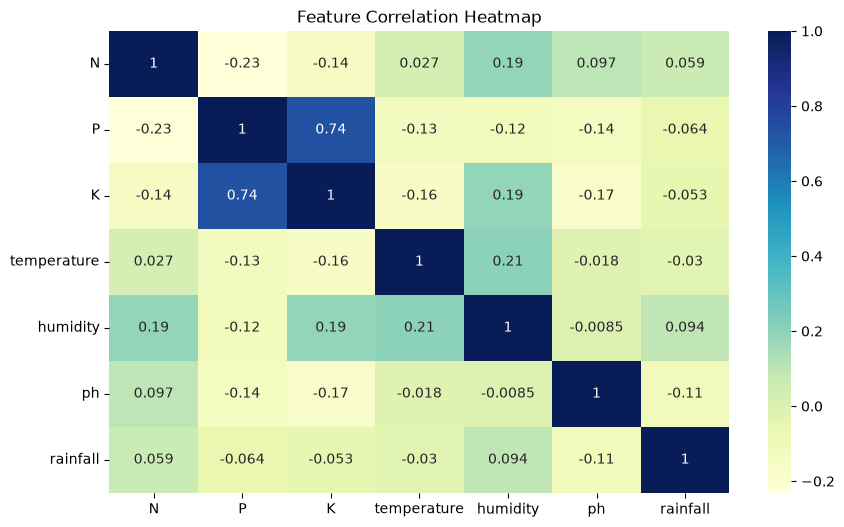

In [28]:
# Correlation heatmap between features
plt.figure(figsize=(10,6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='YlGnBu')
plt.title("Feature Correlation Heatmap")
plt.show()

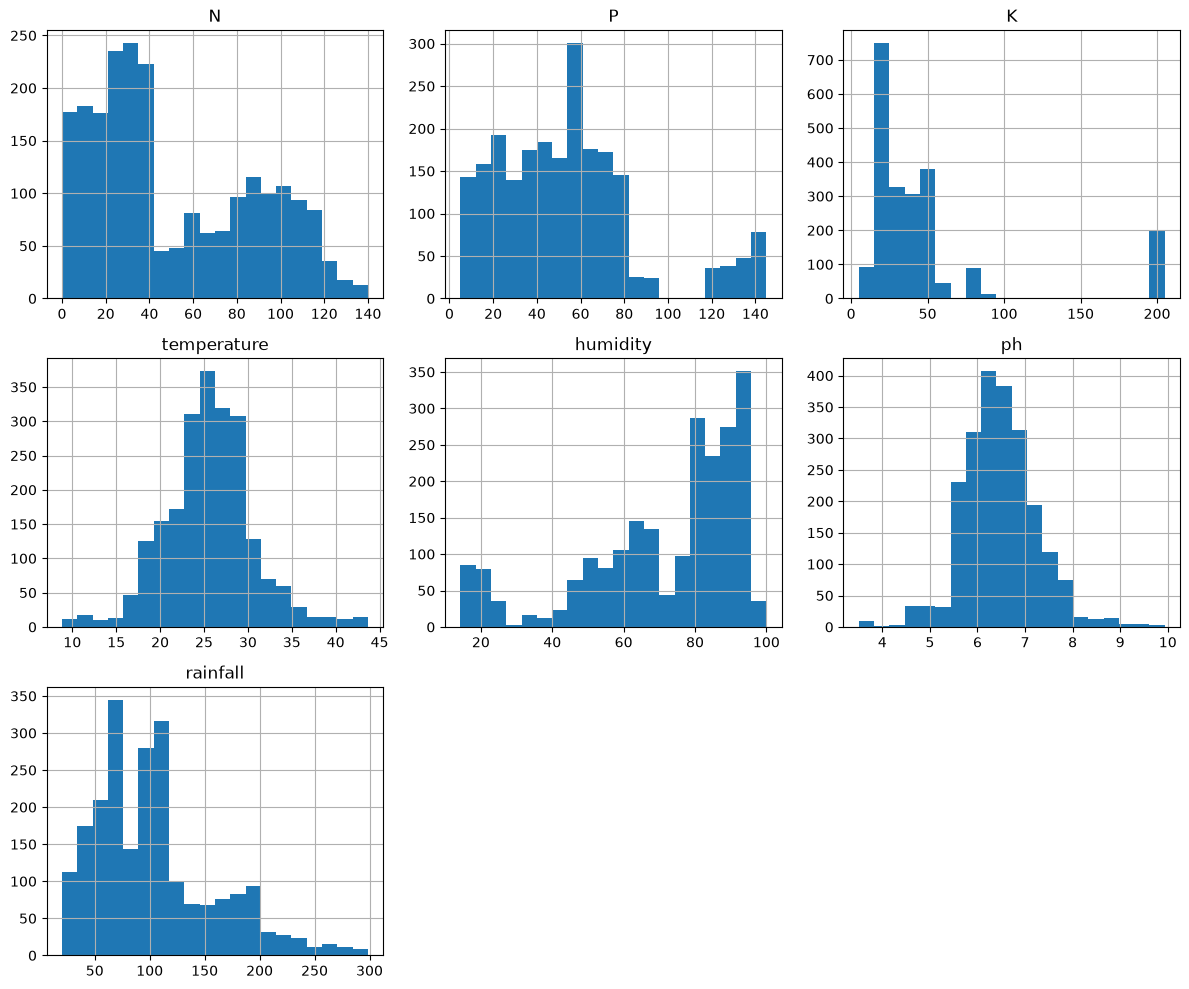

In [29]:
# Distribution of each feature
df.drop('label', axis=1).hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

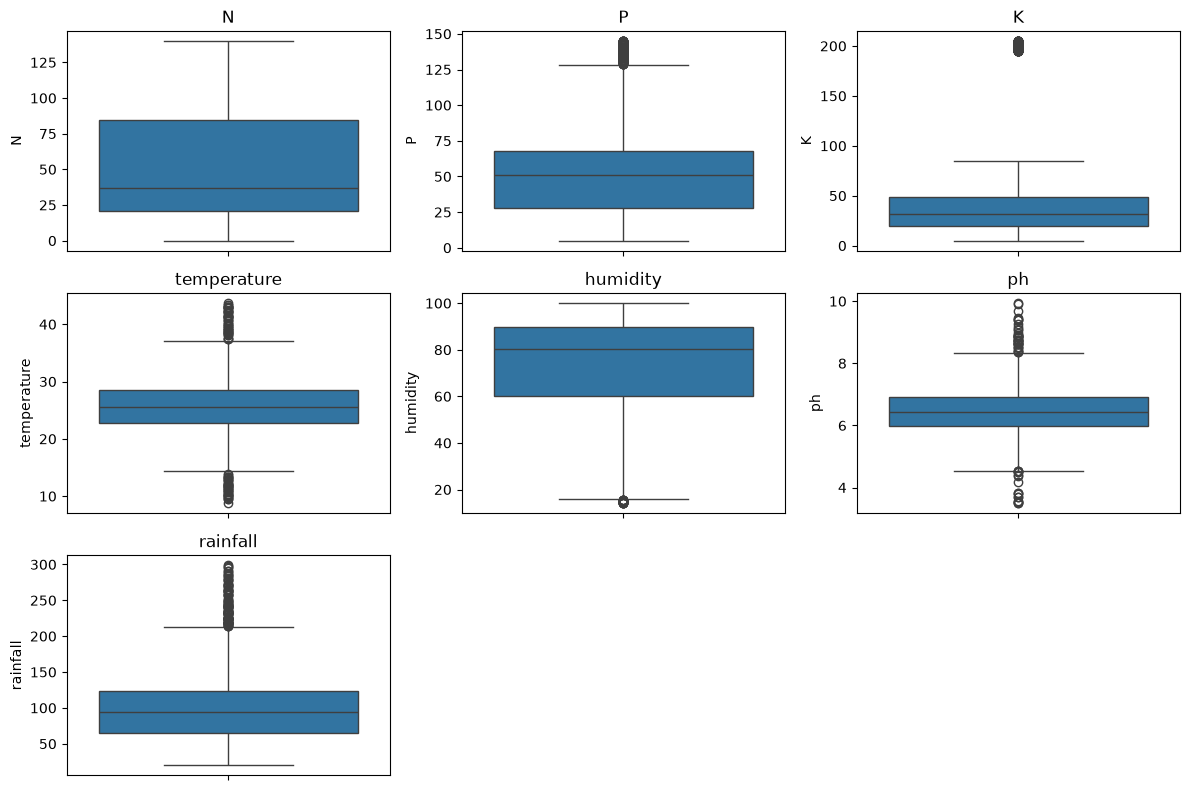

In [30]:
# Boxplots to check outliers
plt.figure(figsize=(12,8))
for i, col in enumerate(['N','P','K','temperature','humidity','ph','rainfall']):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Outlier Detection & Treatment (IQR Method)

Number of outliers in K: 200
Lower bound: -23.5 Upper bound: 92.5


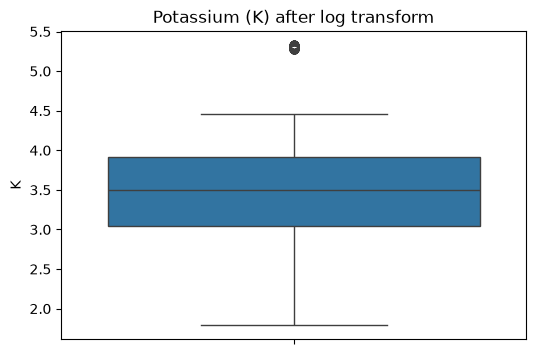

In [31]:
# Detect outliers using IQR method
Q1 = df['K'].quantile(0.25)
Q3 = df['K'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['K'] < lower_bound) | (df['K'] > upper_bound)]
print("Number of outliers in K:", outliers.shape[0])
print("Lower bound:", lower_bound, "Upper bound:", upper_bound)

# Log transform to reduce skew/outlier impact on Potassium
df['K'] = np.log1p(df['K'])

# Confirm the transform worked
plt.figure(figsize=(6,4))
sns.boxplot(y=df['K'])
plt.title("Potassium (K) after log transform")
plt.show()

## Bivariate Analysis: Humidity vs Crop Label

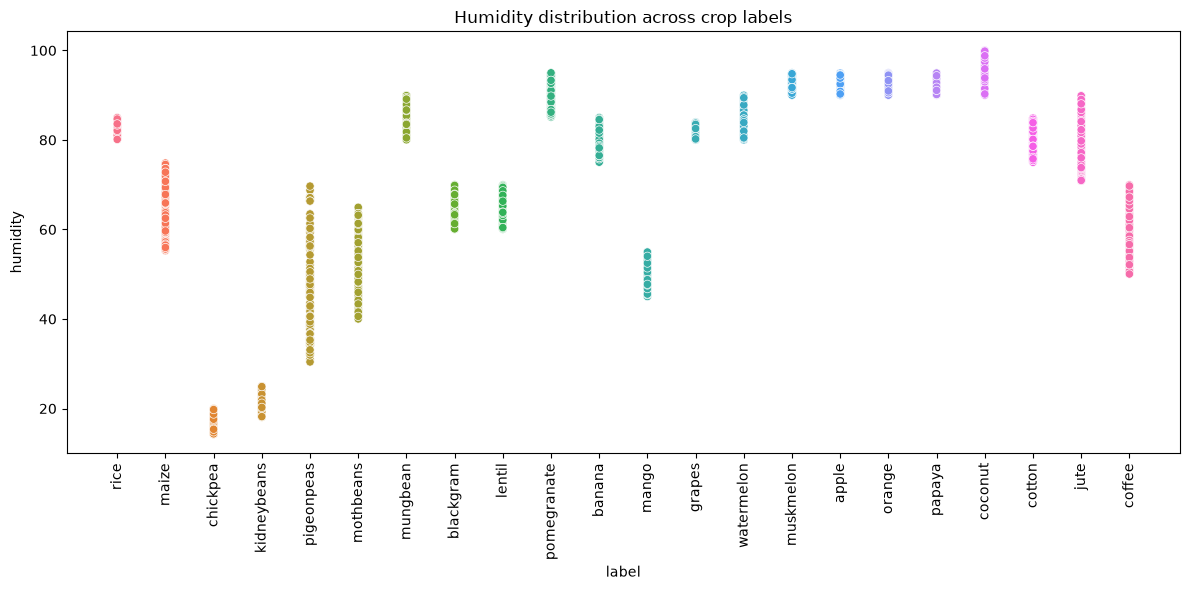

In [32]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='label', y='humidity', hue='label', legend=False)
plt.xticks(rotation=90)
plt.title("Humidity distribution across crop labels")
plt.tight_layout()
plt.show()

## Multivariate Analysis: Feature Patterns Across Crops

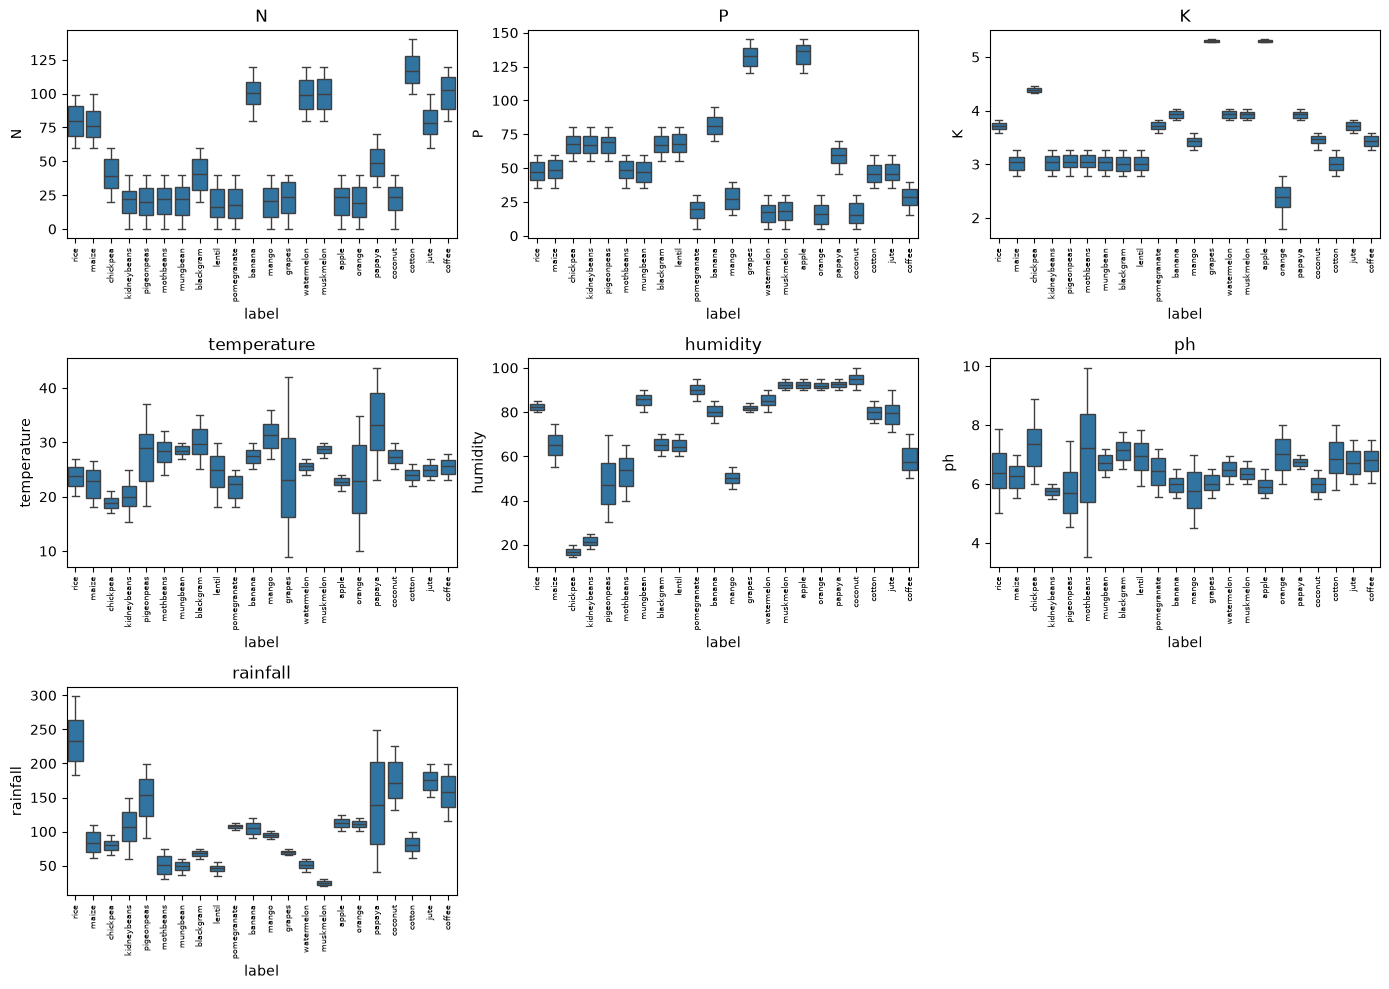

In [33]:
plt.figure(figsize=(14,10))
features = ['N','P','K','temperature','humidity','ph','rainfall']
for i, col in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.boxplot(data=df, x='label', y=col)
    plt.xticks(rotation=90, fontsize=6)
    plt.title(col)
plt.tight_layout()
plt.show()

## Seasonal Crop Grouping

season
Summer            1635
Winter (Rabi)      433
Rainy (Kharif)     132
Name: count, dtype: int64


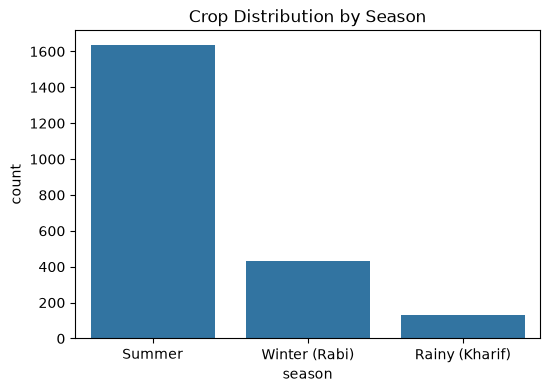

season
Rainy (Kharif)                              [rice, papaya, coconut]
Summer            [rice, maize, kidneybeans, pigeonpeas, mothbea...
Winter (Rabi)     [rice, maize, chickpea, kidneybeans, pigeonpea...
Name: label, dtype: object

In [34]:
def assign_season(row):
    # Simple rule-based grouping using temperature, humidity, and rainfall
    if row['rainfall'] > 200:
        return 'Rainy (Kharif)'
    elif row['temperature'] < 22:
        return 'Winter (Rabi)'
    else:
        return 'Summer'

df['season'] = df.apply(assign_season, axis=1)
print(df['season'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='season', order=df['season'].value_counts().index)
plt.title("Crop Distribution by Season")
plt.show()

df.groupby('season')['label'].unique()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Separate features and target
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[feature_cols]
y = df['label']

# Encode crop names into numbers (rice=0, maize=1, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split into train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1760, 7)
Test size: (440, 7)


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features (Logistic Regression works better with scaled data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


## Model Evaluation: Logistic Regression

Accuracy : 0.9727
Precision: 0.9742
Recall   : 0.9727
F1-Score : 0.9725


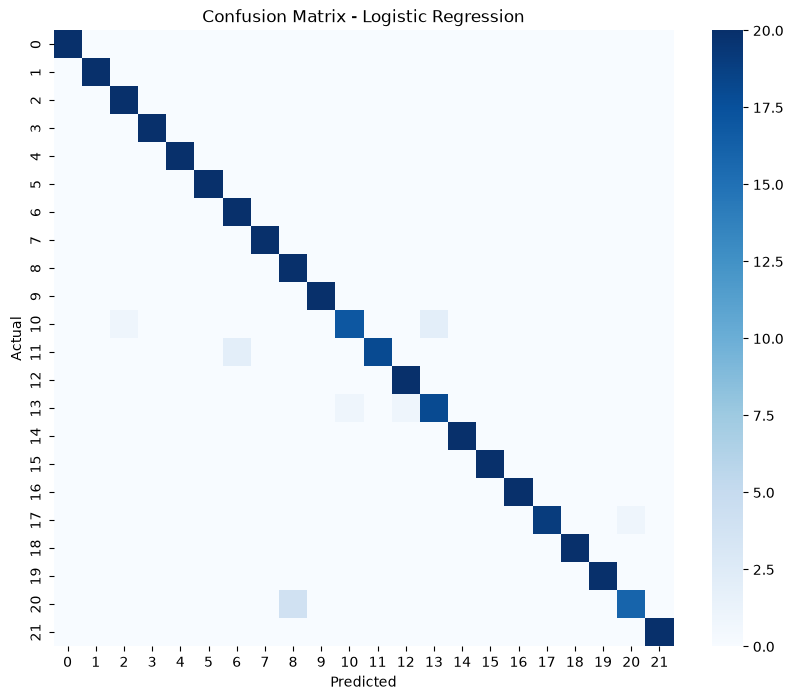

ROC-AUC Score: 0.9998


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-Score :", round(f1, 4))

# Confusion matrix
plt.figure(figsize=(10,8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC-AUC (multi-class, one-vs-rest)
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
y_prob = model.predict_proba(X_test_scaled)
roc_auc = roc_auc_score(y_test_bin, y_prob, average='weighted', multi_class='ovr')
print("ROC-AUC Score:", round(roc_auc, 4))

## K-Means Clustering

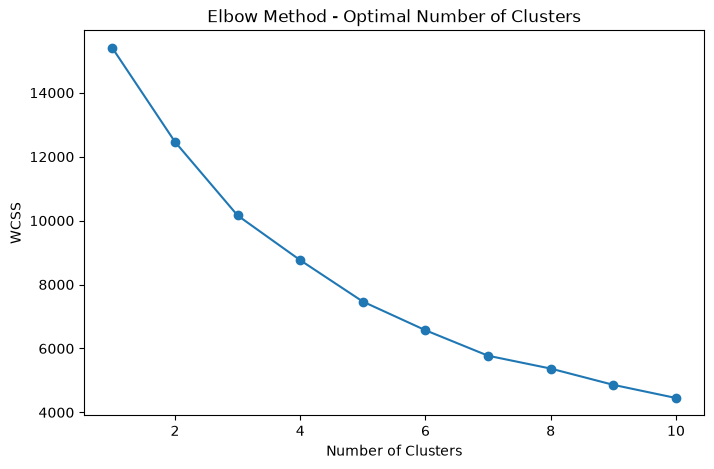

In [38]:
from sklearn.cluster import KMeans

# Use the same scaler-fitted feature set (numeric columns only, excluding season/label)
X_cluster = df[['N','P','K','temperature','humidity','ph','rainfall']]
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [39]:
# Based on the elbow graph above, choose the optimal k (commonly 3-4 for this dataset)
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

print(df['Cluster'].value_counts())
df.groupby('Cluster')[['N','P','K','temperature','humidity','ph','rainfall']].mean()

Cluster
0    819
1    621
2    560
3    200
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall
Cluster,,,,,,,
0,26.837607,57.240537,3.240461,26.011133,50.916370,6.535444,79.058030
1,48.140097,32.512077,3.433469,25.129651,85.408662,6.548848,165.302252
2,98.108929,42.237500,3.615226,26.426881,80.535298,6.460594,74.985993
3,21.990000,133.375000,5.303172,23.240259,87.104305,5.977800,91.133304


## Save the Trained Model

In [40]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model, scaler, and label encoder saved successfully.")

Model, scaler, and label encoder saved successfully.


## Conclusion

This project set out to build a data-driven crop recommendation system using the Crop Recommendation dataset, combining supervised classification with unsupervised pattern discovery.

**Classification results:** A Logistic Regression model, trained on standardized soil and climate features (N, P, K, temperature, humidity, pH, rainfall), achieved strong performance on the held-out test set:
- Accuracy: **97.27%**
- Precision: **97.42%**
- Recall: **97.27%**
- F1-Score: **97.25%**
- ROC-AUC: **0.9998**

These results indicate the model reliably distinguishes between the 22 crop classes using only basic soil and weather measurements, making it practical for real-world advisory use where lab-grade soil testing may be limited.

**Seasonal grouping:** Rule-based grouping by rainfall and temperature split crops into Rainy (Kharif), Winter (Rabi), and Summer categories, giving an interpretable, agronomically meaningful view of when each crop is typically grown — useful as a sanity check alongside the ML predictions.

**Clustering insights:** K-Means (k=4, chosen via the elbow method) revealed natural groupings in the feature space independent of crop labels:
- Cluster 0 (819 samples): moderate N, high P, low rainfall
- Cluster 1 (621 samples): moderate N/P, high humidity, high rainfall
- Cluster 2 (560 samples): high N, moderate P/humidity
- Cluster 3 (200 samples): low N, very high P and rainfall, lower pH

These clusters suggest the dataset naturally organizes around distinct soil-nutrient and moisture profiles, which could be used to pre-group farms or fields before applying the classifier, or to flag unusual/outlier soil conditions.

**Overall**, the combination of a high-accuracy classifier, an interpretable seasonal rule, and exploratory clustering gives a well-rounded system: the classifier for direct crop recommendation, and the seasonal/cluster analysis for explaining *why* a recommendation makes sense. Future work could explore ensemble models (Random Forest, XGBoost) for comparison, incorporate soil type or geographic region as features, and deploy the saved model/scaler/encoder behind a simple API for real-time recommendations.